In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\samco\OneDrive\LP\Repositorios DEV\EBAC_Estudos\EBAC\Pre_processamento_dados\CHURN_CREDIT_MOD14.csv', delimiter=';')

df.head(10)

C:\Users\samco\AppData\Local\Temp\ipykernel_15768\2412550074.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\samco\OneDrive\LP\Repositorios DEV\EBAC_Estudos\EBAC\Pre_processamento_dados\CHURN_CREDIT_MOD14.csv', delimiter=';')


,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,15813451,Fleetwood-Smith,677,Spain,Male,18.0,5,134796.87,2,1.0,0.0,114858.9,0.0
1,15641688,Collier,644,Spain,Female,18.0,7,0.00,1,0.0,1.0,74564.41,0.0
2,15757821,Burgess,641,Spain,Male,18.0,1,0.00,2,0.0,1.0,41542.95,0.0
3,15673180,Onyekaozulu,826,Spain,Male,18.0,2,0.00,2,0.0,1.0,16245.25,0.0
4,15664543,Tuan,774,Spain,Female,18.0,1,185891.54,1,1.0,0.0,175072.41,0.0
5,15673180,Onyekaozulu,688,Spain,Female,18.0,2,0.00,2,1.0,0.0,98349.13,0.0
6,15641688,Collier,803,Spain,Male,18.0,6,0.00,1,0.0,0.0,59645.24,1.0
7,15672940,Yevseyev,578,Spain,Female,18.0,8,71843.15,2,0.0,1.0,112649.22,0.0
8,15694192,Nwankwo,598,Spain,Male,18.0,6,0.00,2,0.0,1.0,173783.38,0.0
9,15585867,Iroawuchi,624,Spain,Female,18.0,6,0.00,2,0.0,1.0,117038.96,0.0


Ver tipo de cada coluna

In [3]:
df.dtypes

CustomerId         int64
Sobrenome         object
Credit_Score       int64
Pais              object
Genero            object
Idade            float64
Tempo_Credito      int64
Balance          float64
Qtd_Produtos       int64
Possui_Cartao    float64
Membro_Ativo     float64
Salario_Anual     object
Churn            float64
dtype: object

Overview do dataframe

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   CustomerId     100000 non-null  int64  
 1   Sobrenome      100000 non-null  object 
 2   Credit_Score   100000 non-null  int64  
 3   Pais           100000 non-null  object 
 4   Genero         99990 non-null   object 
 5   Idade          99794 non-null   float64
 6   Tempo_Credito  100000 non-null  int64  
 7   Balance        100000 non-null  float64
 8   Qtd_Produtos   100000 non-null  int64  
 9   Possui_Cartao  100000 non-null  float64
 10  Membro_Ativo   100000 non-null  float64
 11  Salario_Anual  100000 non-null  object 
 12  Churn          99911 non-null   float64
dtypes: float64(5), int64(4), object(4)
memory usage: 9.9+ MB


Trocar tipo de dados da coluna Salario_Anual

In [5]:
# df['Salario_Anual'] = df['Salario_Anual'].astype(float)
# Vai dar erro porque tem um valor que não é numérico, aparentemente porque tem pontos em alguns valores ao inves de virgulas
# Para corrigir:
# Removendo os pontos da coluna
df['Salario_Anual'] = df['Salario_Anual'].str.replace('.', '', regex = False)

# Convertendo denovo
df['Salario_Anual'] = df['Salario_Anual'].astype(float)




Verificando tipo de dados novamente

In [6]:
df.dtypes

CustomerId         int64
Sobrenome         object
Credit_Score       int64
Pais              object
Genero            object
Idade            float64
Tempo_Credito      int64
Balance          float64
Qtd_Produtos       int64
Possui_Cartao    float64
Membro_Ativo     float64
Salario_Anual    float64
Churn            float64
dtype: object

Procurando dados nulos

In [7]:
df.isnull().sum() # Soma dos valores nulos por coluna
#(df.isnull().sum() / len(df)) * 100 # Porcentagem de valores nulos por coluna

CustomerId           0
Sobrenome            0
Credit_Score         0
Pais                 0
Genero              10
Idade              206
Tempo_Credito        0
Balance              0
Qtd_Produtos         0
Possui_Cartao        0
Membro_Ativo         0
Salario_Anual    65536
Churn               89
dtype: int64

Corrigindo valores nulos da coluna Gênero

In [8]:
df[df['Genero'].isnull()] #Exibe as linhas que tem valores nulos na coluna 'Genero'

df.dropna(subset=['Genero'], inplace=True) # Remove as linhas que tem valores nulos na coluna genero(o inplace=True faz a alteração direto no dataframe, sem precisar criar um novo)

Corrigindo valores nulos da coluna Idade

In [9]:
df.dropna(subset=['Idade'], inplace=True)

Corrigindo valores nulos da coluna Salário

In [10]:
# Verificando a media
df['Salario_Anual'].mean()


np.float64(10280264.388924362)

In [11]:
# Verificando a mediana
df['Salario_Anual'].median()

np.float64(10787643.5)

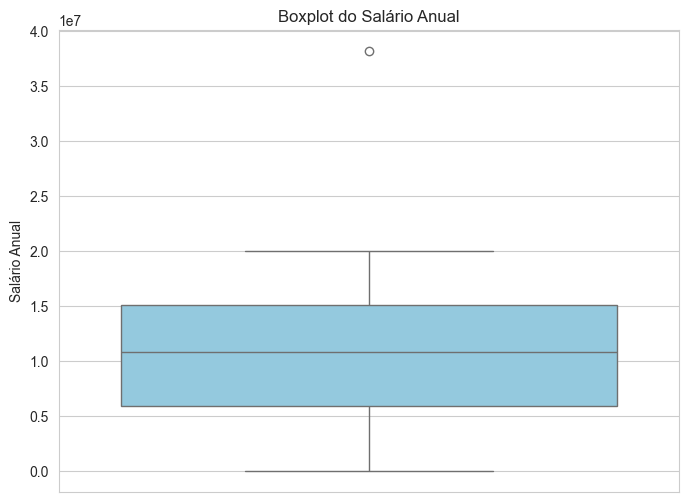

In [12]:
# Trazendo gráfico de boxplot para visualização dos dados

sns.set_style('whitegrid') # Função para definir o estilo estético do gráfico diretamente

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Salario_Anual', color='skyblue')
plt.title('Boxplot do Salário Anual')
plt.ylabel('Salário Anual')
plt.show()


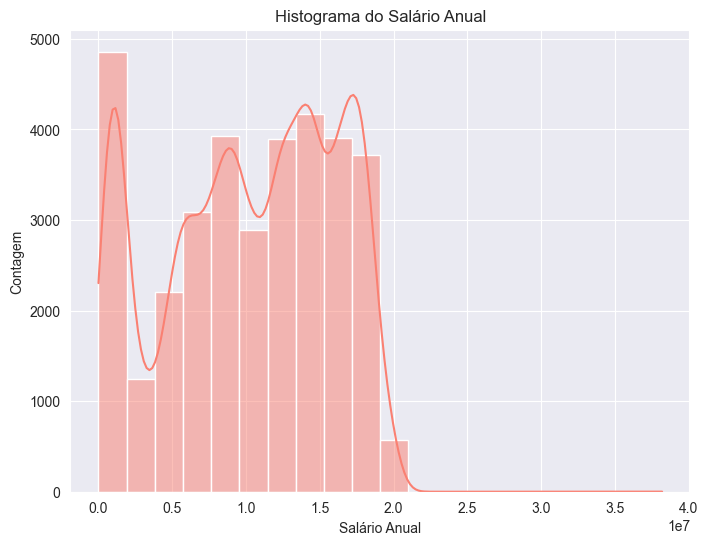

In [13]:
# Gráfico de barras para visualização

sns.set_style('darkgrid')

plt.figure(figsize=(8, 6) )
sns.histplot(data=df, x='Salario_Anual', bins=20, kde=True, color='salmon')
plt.title('Histograma do Salário Anual')
plt.xlabel('Salário Anual')
plt.ylabel('Contagem')
plt.show()  

In [14]:
# Trazendo a mediana removendo o outlier(salarios acima de 20 milhoes)

salario_menor2m = df[df['Salario_Anual'] < 20000000]
salario_menor2m['Salario_Anual'].median()

np.float64(10787603.0)

In [15]:
# Calculando a mediana dos salários menores que 20 milhões
mediana_20m = df[df['Salario_Anual'] < 20000000]['Salario_Anual'].median()

In [16]:
# Substituindo os valores nulos pela mediana dos salários menores que 20 milhões
df['Salario_Anual'].fillna(mediana_20m, inplace=True)

C:\Users\samco\AppData\Local\Temp\ipykernel_15768\2144646840.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salario_Anual'].fillna(mediana_20m, inplace=True)


Corrigindo a coluna Churn

<Axes: xlabel='Churn', ylabel='Count'>

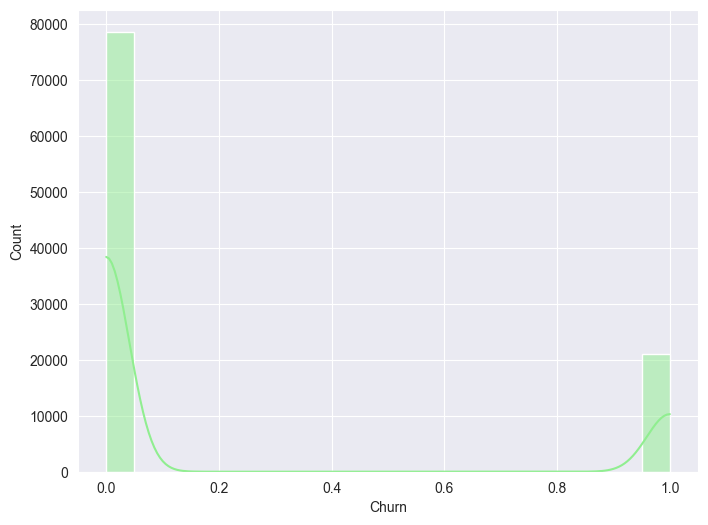

In [17]:
# Criando um histograma para analizar o balanceamento dos dados na coluna

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Churn', bins=20, kde=True, color='lightgreen')

In [18]:
# Realizando a contagem dos valores únicos na coluna 'Churn'
df['Churn'].value_counts(normalize = True) * 100 

Churn
0.0    78.854254
1.0    21.145746
Name: proportion, dtype: float64

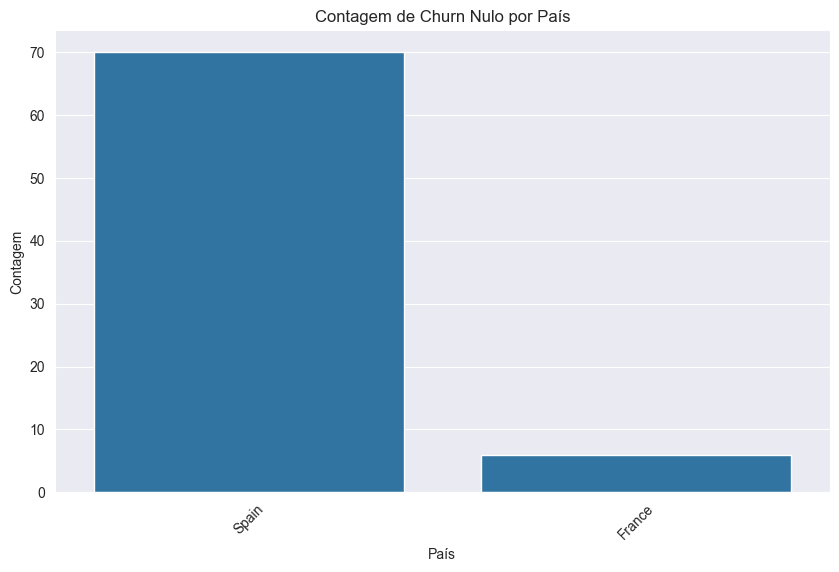

In [19]:
# Criando gráficos para verificar se existe padrão nos dados nulos

df_churn_nulo = df[df['Churn'].isnull()] # Seleciona todas as linhas onde a coluna churn é nula

plt.figure(figsize=(10, 6))
sns.countplot(data=df_churn_nulo, x='Pais')
plt.title('Contagem de Churn Nulo por País')
plt.xlabel('País')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

# O resultado indica que se trocar os valores nulos para não churn pode acabar enviezando o modelo, pois a maioria dos nulos sao da Espanha

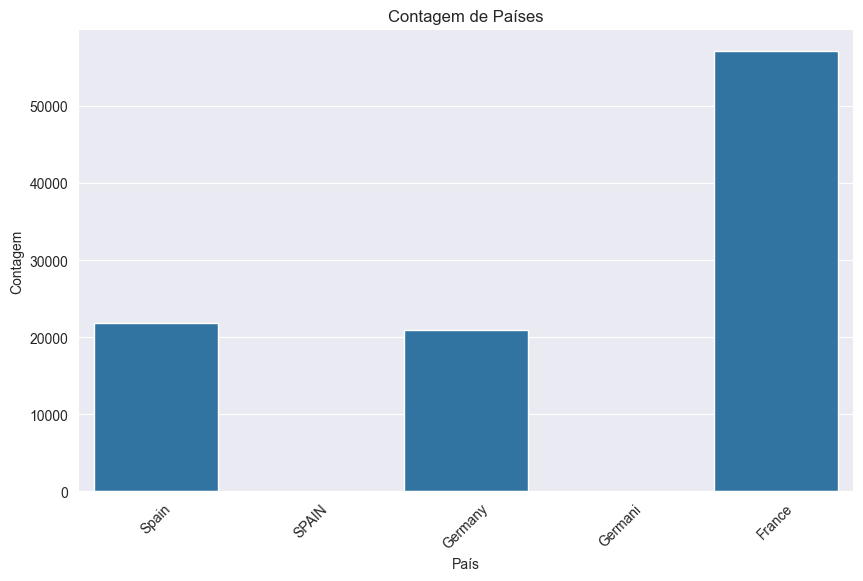

In [20]:
# Criando um gráfico da coluna País para ver a porcentagem de dados da Espanha em relação ao Total

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pais')
plt.title('Contagem de Países')
plt.xlabel('País')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

In [21]:
# Sendo a Espanha uma pequena parte do total de dados, a melhor decisão aqui é remover os dados nulos da coluna

df.dropna(subset=['Churn'], inplace=True)

In [22]:
# Transformando os dados da coluna churn para Booleano

df['Churn'] = df['Churn'].astype(bool)  

In [23]:
df['Churn']

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999     True
Name: Churn, Length: 99708, dtype: bool

Modificando nomes das colunas

In [24]:
# Traduzindo a coluna "balance"

df.rename(columns={'Balance' : 'Balanco'}, inplace=True)
df.head()

,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,15813451,Fleetwood-Smith,677,Spain,Male,18.0,5,134796.87,2,1.0,0.0,10787603.0,False
1,15641688,Collier,644,Spain,Female,18.0,7,0.00,1,0.0,1.0,10787603.0,False
2,15757821,Burgess,641,Spain,Male,18.0,1,0.00,2,0.0,1.0,10787603.0,False
3,15673180,Onyekaozulu,826,Spain,Male,18.0,2,0.00,2,0.0,1.0,10787603.0,False
4,15664543,Tuan,774,Spain,Female,18.0,1,185891.54,1,1.0,0.0,10787603.0,False


Corrigindo dados da coluna País

In [25]:
df['Pais'].unique()

array(['Spain', 'SPAIN', 'Germany', 'Germani', 'France'], dtype=object)

In [26]:
# Transformando todos os dados da coluna país para maiúsculo

df['Pais'] = df['Pais'].str.upper() # Ou lower() para minusculo
df['Pais'].unique()

array(['SPAIN', 'GERMANY', 'GERMANI', 'FRANCE'], dtype=object)

In [27]:
# Substituição dos valores escritos errados

df['Pais'] = df['Pais'].replace('GERMANI', 'GERMANY')

df['Pais'].unique()

# É bom fazer a verificação de todas as variáveis categóricas importantes

array(['SPAIN', 'GERMANY', 'FRANCE'], dtype=object)

Removendo colunas que não são importantes

In [28]:
# É bom fazer isso no início do processo de tratamento dos dados

df.drop(columns=['Sobrenome'], inplace=True)

df.drop(columns=['CustomerId'], inplace=True)

In [ ]:
df.to_csv('CHURN_CREDIT_MOD14.csv', index=False) # Salvar o arquivo tratado, sem o index, para não criar uma nova coluna com os indices do dataframe 